First 5 rows:
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-04

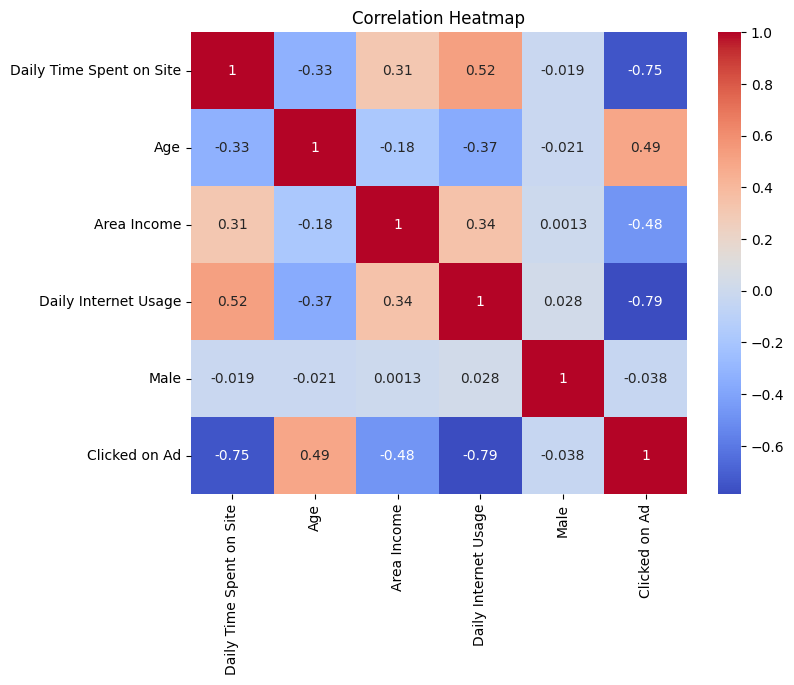


Model Coefficients:
[[-2.52553311  1.25056071 -1.63704805 -2.70402918 -0.35862744]]
Intercept: [1.47571247]

K-Fold CV Scores: [0.96  0.98  0.985 0.96  0.97 ]
Mean Accuracy: 0.9709999999999999

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



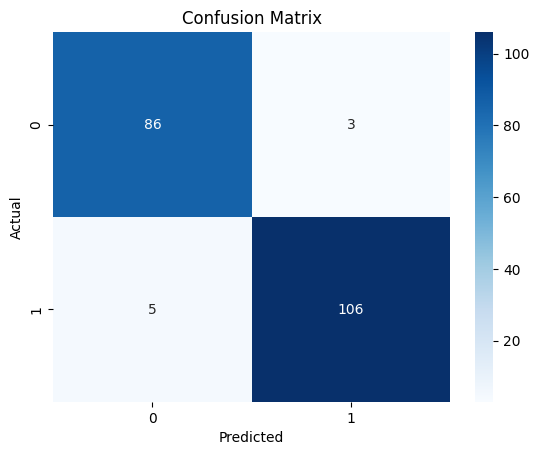

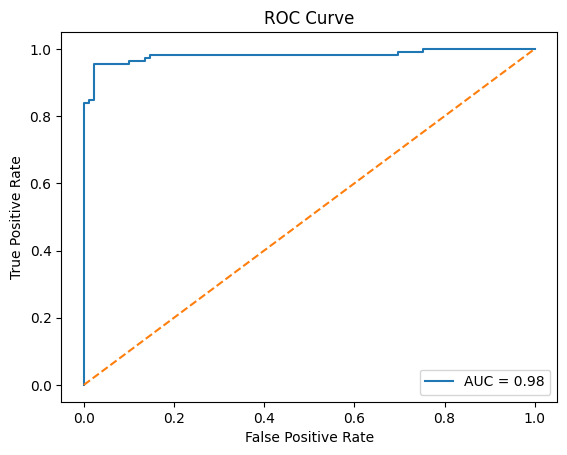

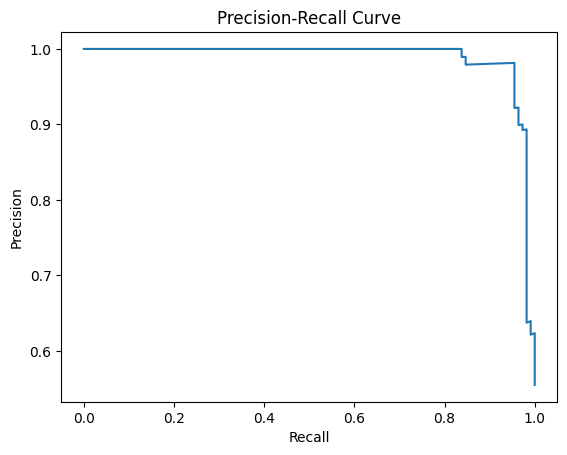

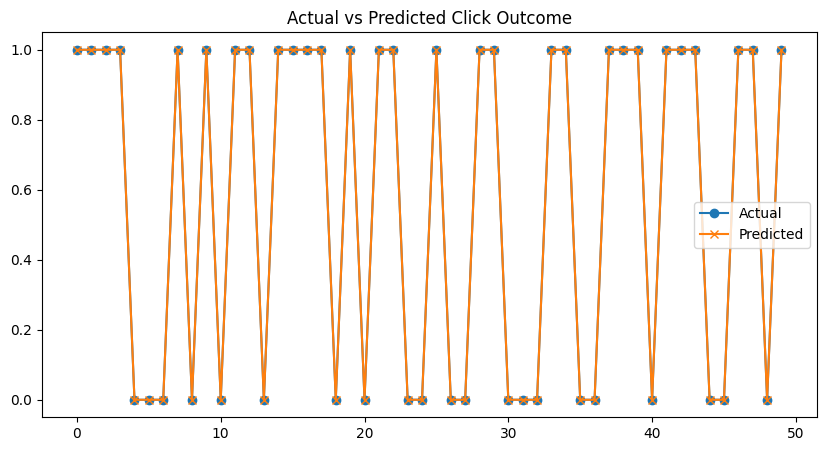

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

# Load Dataset
df = pd.read_csv("advertising.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# Missing Value Check
print("\nMissing Values:")
print(df.isnull().sum())

# Feature Selection
X = df[
    [
        "Daily Time Spent on Site",
        "Age",
        "Area Income",
        "Daily Internet Usage",
        "Male"  # already encoded
    ]
]

y = df["Clicked on Ad"]


# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Correlation Heatmap (NUMERIC ONLY)

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

print("\nModel Coefficients:")
print(model.coef_)
print("Intercept:", model.intercept_)

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=kf)

print("\nK-Fold CV Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

# Classification Report
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual", marker="o")
plt.plot(y_pred[:50], label="Predicted", marker="x")
plt.legend()
plt.title("Actual vs Predicted Click Outcome")
plt.show()